# Final Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

metrics_path = '../Results/all_models_metrics.csv'
df = pd.read_csv(metrics_path)

MODEL_ORDER = ['KNN', 'DT', 'RF', 'NB', 'SVM', 'ANN']
df['Model'] = pd.Categorical(df['Model'], categories=MODEL_ORDER, ordered=True)
df = df.sort_values(['Model', 'Task', 'Features']).reset_index(drop=True)

print(f'Loaded {len(df)} records covering {df["Model"].nunique()} models.')
df

Loaded 24 records covering 6 models.


,Model,Task,Features,Best_Param,CV_Score,Val_Acc,Val_F1,Train_Time
0,KNN,Binary,Raw,"{'metric': 'euclidean', 'n_neighbors': 1, 'wei...",0.9949,0.9988,0.9987,0.00
1,KNN,Binary,Reduced,"{'metric': 'euclidean', 'n_neighbors': 1, 'wei...",0.9944,0.9975,0.9975,0.00
2,KNN,Multiclass,Raw,"{'metric': 'euclidean', 'n_neighbors': 1, 'wei...",0.9892,0.9900,0.9900,0.00
3,KNN,Multiclass,Reduced,"{'metric': 'euclidean', 'n_neighbors': 1, 'wei...",0.9444,0.9637,0.9638,0.00
4,DT,Binary,Raw,"{'class_weight': None, 'criterion': 'entropy',...",0.9871,0.9875,0.9874,0.02
5,DT,Binary,Reduced,"{'class_weight': None, 'criterion': 'gini', 'm...",0.9942,0.9938,0.9938,0.04
6,DT,Multiclass,Raw,"{'class_weight': None, 'criterion': 'entropy',...",0.7617,0.7538,0.7402,0.02
7,DT,Multiclass,Reduced,"{'class_weight': None, 'criterion': 'gini', 'm...",0.7433,0.7475,0.7452,0.04
8,RF,Binary,Raw,"{'max_depth': 12, 'max_features': 'sqrt', 'min...",0.9928,0.9938,0.9937,0.09
9,RF,Binary,Reduced,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.9984,0.9988,0.9987,0.09


In [ ]:
# Pivot tables: Val_Acc and Val_F1 for every Model × Task × Features
pivot_acc = df.pivot_table(
    index='Model',
    columns=['Task', 'Features'],
    values='Val_Acc',
    observed=False
).round(4)

pivot_f1 = df.pivot_table(
    index='Model',
    columns=['Task', 'Features'],
    values='Val_F1',
    observed=False
).round(4)

pivot_cv = df.pivot_table(
    index='Model',
    columns=['Task', 'Features'],
    values='CV_Score',
    observed=False
).round(4)

print('Validation Accuracy')
display(pivot_acc)
print('\nValidation F1-Score')
display(pivot_f1)
print('\nCV Score (5-fold balanced_accuracy)')
display(pivot_cv)

=== Validation Accuracy ===


Task      Binary         Multiclass        
Features     Raw Reduced        Raw Reduced
Model                                      
KNN       0.9988  0.9975     0.9900  0.9637
DT        0.9875  0.9938     0.7538  0.7475
RF        0.9938  0.9988     0.8500  0.8113
NB        0.9663  0.9925     0.6913  0.6587
SVM       0.9988  1.0000     0.9700  0.8462
ANN       0.9988  0.9988     0.9700  0.8875


=== Validation F1-Score ===


Task      Binary         Multiclass        
Features     Raw Reduced        Raw Reduced
Model                                      
KNN       0.9987  0.9975     0.9900  0.9638
DT        0.9874  0.9938     0.7402  0.7452
RF        0.9937  0.9987     0.8485  0.8098
NB        0.9666  0.9925     0.6845  0.6404
SVM       0.9987  1.0000     0.9700  0.8446
ANN       0.9987  0.9988     0.9701  0.8877


=== CV Score (5-fold balanced_accuracy) ===


Task      Binary         Multiclass        
Features     Raw Reduced        Raw Reduced
Model                                      
KNN       0.9949  0.9944     0.9892  0.9444
DT        0.9871  0.9942     0.7617  0.7433
RF        0.9928  0.9984     0.8572  0.8258
NB        0.9706  0.9918     0.7149  0.6603
SVM       0.9978  0.9991     0.9535  0.8444
ANN       0.9986  0.9981     0.9540  0.8697

Validation Accuracy: Raw vs. PCA-Reduced Features

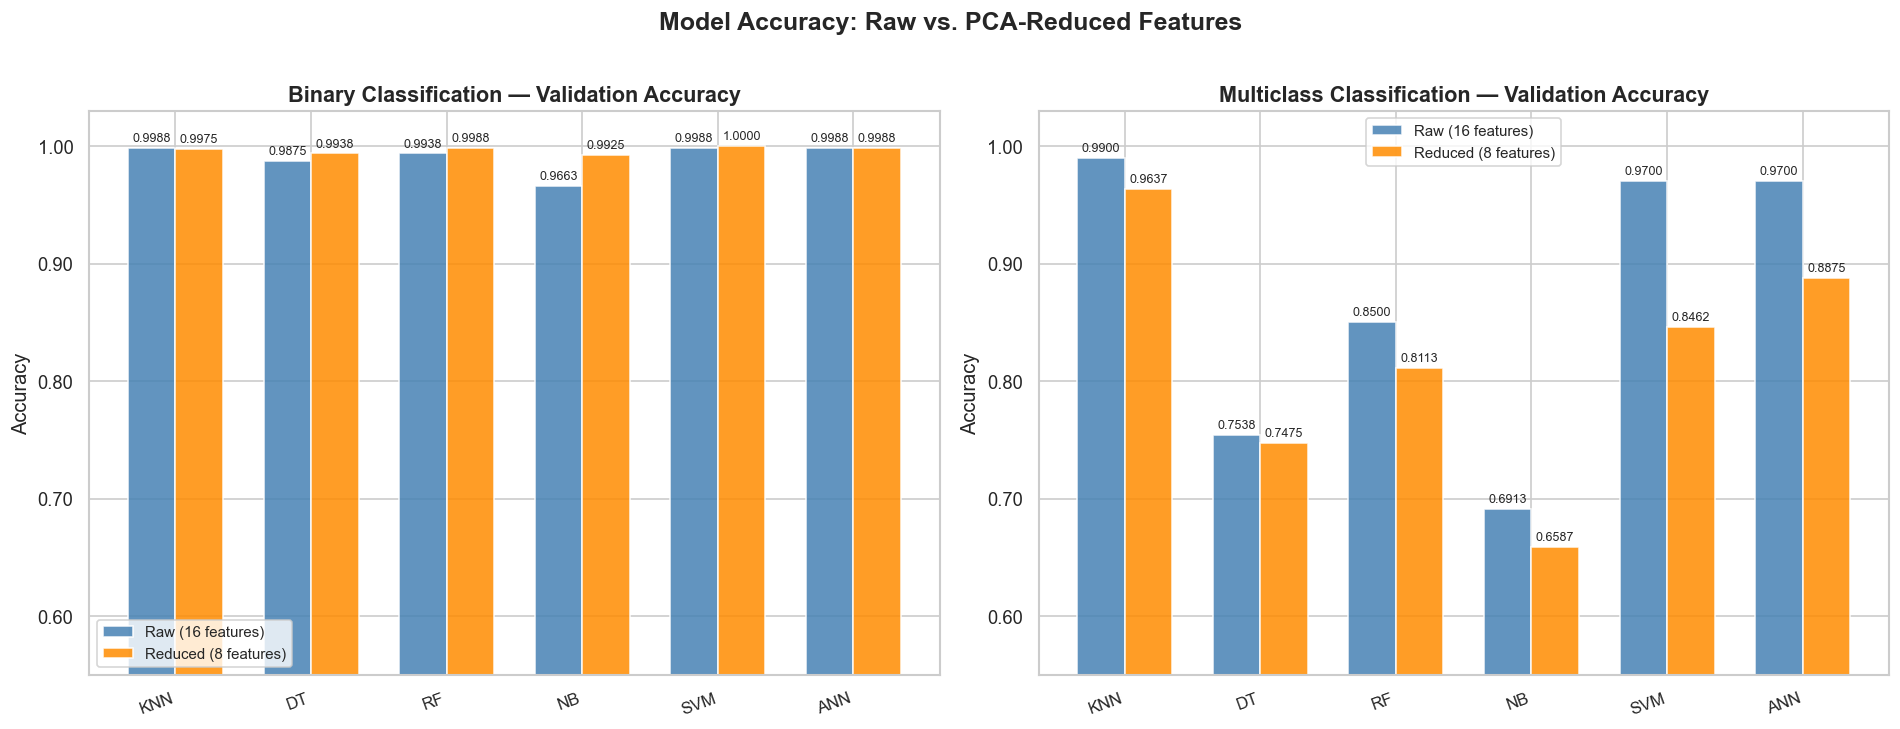

Saved: ../Results/Final_Accuracy_Comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, task in zip(axes, ['Binary', 'Multiclass']):
    sub = df[df['Task'] == task].copy()
    x   = np.arange(len(MODEL_ORDER))
    w   = 0.35

    raw_vals = [
        sub.loc[(sub['Model'] == m) & (sub['Features'] == 'Raw'), 'Val_Acc'].values[0]
        if len(sub.loc[(sub['Model'] == m) & (sub['Features'] == 'Raw')]) else np.nan
        for m in MODEL_ORDER
    ]
    red_vals = [
        sub.loc[(sub['Model'] == m) & (sub['Features'] == 'Reduced'), 'Val_Acc'].values[0]
        if len(sub.loc[(sub['Model'] == m) & (sub['Features'] == 'Reduced')]) else np.nan
        for m in MODEL_ORDER
    ]

    bars1 = ax.bar(x - w/2, raw_vals, w, label='Raw (16 features)', color='steelblue',  alpha=0.85)
    bars2 = ax.bar(x + w/2, red_vals, w, label='Reduced (8 features)', color='darkorange', alpha=0.85)

    ax.set_title(f'{task} Classification — Validation Accuracy', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=20, ha='right', fontsize=10)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.55, 1.03)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=9)

    for bar in bars1 + bars2:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.4f}', ha='center', va='bottom', fontsize=7.5)

fig.suptitle('Model Accuracy: Raw vs. PCA-Reduced Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Results/Final_Accuracy_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../Results/Final_Accuracy_Comparison.png')

F1-Score heatmap

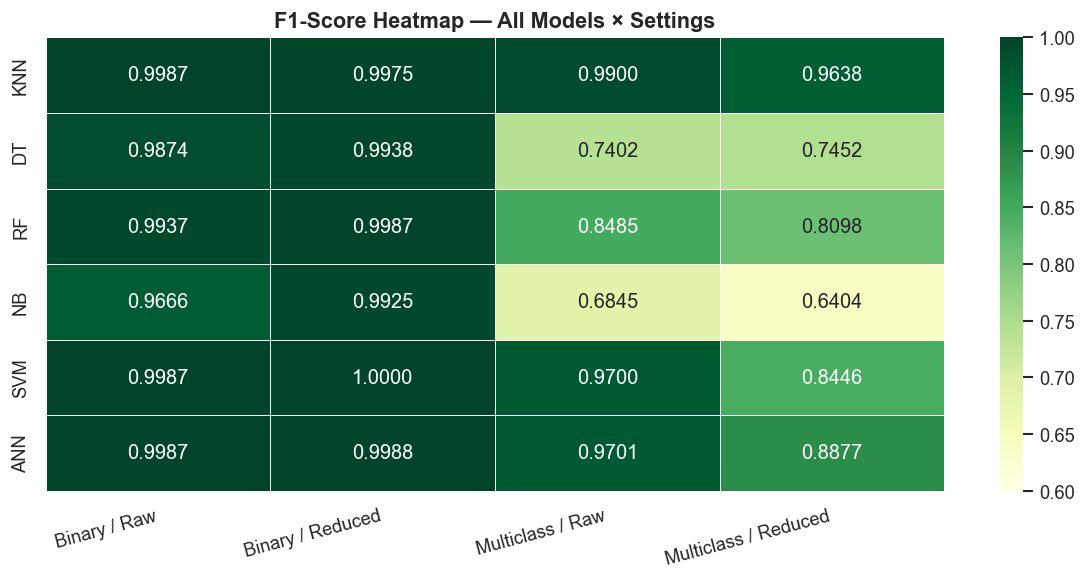

Saved: ../Results/Final_F1_Heatmap.png


In [ ]:
heat_data = df.copy()
heat_data['Setting'] = heat_data['Task'] + ' / ' + heat_data['Features']
heat_pivot = heat_data.pivot_table(
    index='Model', columns='Setting', values='Val_F1', observed=False
)

col_order = ['Binary / Raw', 'Binary / Reduced', 'Multiclass / Raw', 'Multiclass / Reduced']
heat_pivot = heat_pivot[col_order]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heat_pivot, annot=True, fmt='.4f', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    vmin=0.60, vmax=1.00, ax=ax
)
ax.set_title('F1-Score Heatmap — All Models × Settings', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../Results/Final_F1_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../Results/Final_F1_Heatmap.png')

CV Score heatmap (5-fold balanced_accuracy)

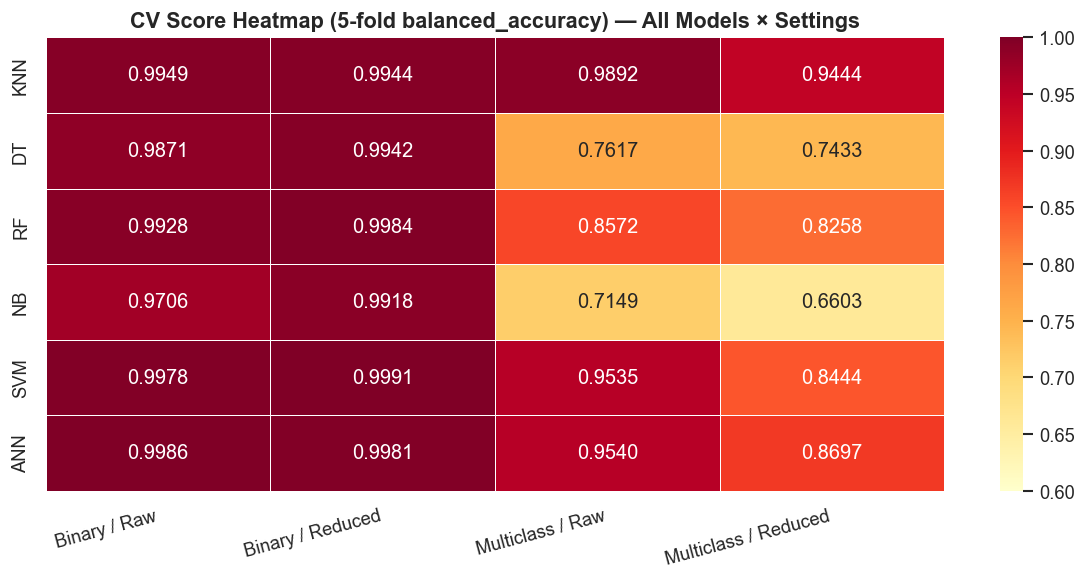

Saved: ../Results/Final_CV_Score_Heatmap.png


In [ ]:
cv_heat = df.copy()
cv_heat['Setting'] = cv_heat['Task'] + ' / ' + cv_heat['Features']
cv_pivot = cv_heat.pivot_table(
    index='Model', columns='Setting', values='CV_Score', observed=False
)

cv_pivot = cv_pivot[col_order]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    cv_pivot, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    vmin=0.60, vmax=1.00, ax=ax
)
ax.set_title('CV Score Heatmap (5-fold balanced_accuracy) — All Models × Settings',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../Results/Final_CV_Score_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../Results/Final_CV_Score_Heatmap.png')

Training time comparison (log scale)

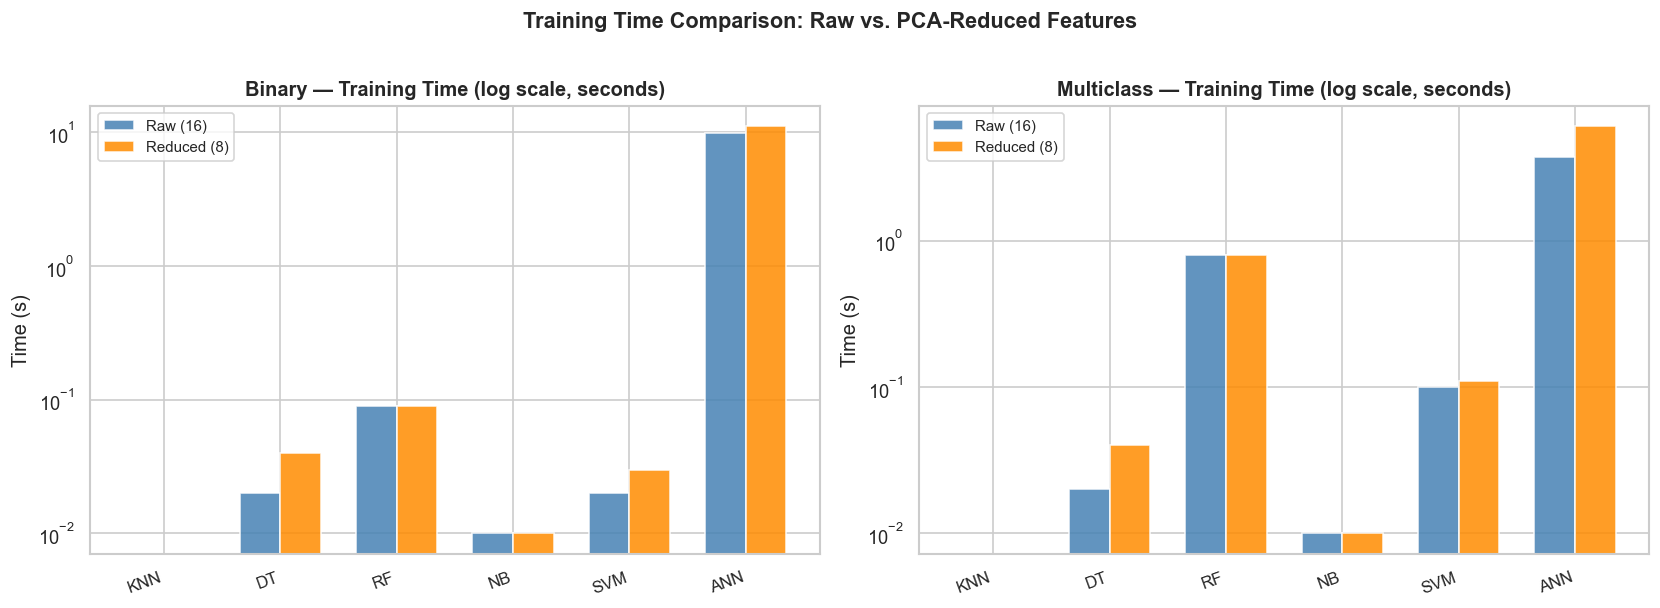

Saved: ../Results/Final_TrainingTime_Comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, task in zip(axes, ['Binary', 'Multiclass']):
    sub = df[df['Task'] == task].copy()
    x   = np.arange(len(MODEL_ORDER))
    w   = 0.35

    raw_t = [
        sub.loc[(sub['Model'] == m) & (sub['Features'] == 'Raw'), 'Train_Time'].values[0]
        if len(sub.loc[(sub['Model'] == m) & (sub['Features'] == 'Raw')]) else np.nan
        for m in MODEL_ORDER
    ]
    red_t = [
        sub.loc[(sub['Model'] == m) & (sub['Features'] == 'Reduced'), 'Train_Time'].values[0]
        if len(sub.loc[(sub['Model'] == m) & (sub['Features'] == 'Reduced')]) else np.nan
        for m in MODEL_ORDER
    ]

    ax.bar(x - w/2, raw_t, w, label='Raw (16)',    color='steelblue',  alpha=0.85)
    ax.bar(x + w/2, red_t, w, label='Reduced (8)', color='darkorange', alpha=0.85)
    ax.set_yscale('log')
    ax.set_title(f'{task} — Training Time (log scale, seconds)', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=20, ha='right', fontsize=10)
    ax.set_ylabel('Time (s)')
    ax.legend(fontsize=9)

fig.suptitle('Training Time Comparison: Raw vs. PCA-Reduced Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Results/Final_TrainingTime_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../Results/Final_TrainingTime_Comparison.png')

Dimensionality reduction impact (Reduced − Raw delta)

=== PCA Impact (Reduced − Raw) ===


,Model,Task,Val_Acc_raw,Val_Acc_red,Acc_Delta,Val_F1_raw,Val_F1_red,F1_Delta
0,KNN,Binary,0.9988,0.9975,-0.0013,0.9987,0.9975,-0.0012
10,ANN,Binary,0.9988,0.9988,0.0000,0.9987,0.9988,0.0001
8,SVM,Binary,0.9988,1.0000,0.0012,0.9987,1.0000,0.0013
4,RF,Binary,0.9938,0.9988,0.0050,0.9937,0.9987,0.0050
2,DT,Binary,0.9875,0.9938,0.0063,0.9874,0.9938,0.0064
6,NB,Binary,0.9663,0.9925,0.0262,0.9666,0.9925,0.0259
9,SVM,Multiclass,0.9700,0.8462,-0.1238,0.9700,0.8446,-0.1254
11,ANN,Multiclass,0.9700,0.8875,-0.0825,0.9701,0.8877,-0.0824
5,RF,Multiclass,0.8500,0.8113,-0.0387,0.8485,0.8098,-0.0387
7,NB,Multiclass,0.6913,0.6587,-0.0326,0.6845,0.6404,-0.0441


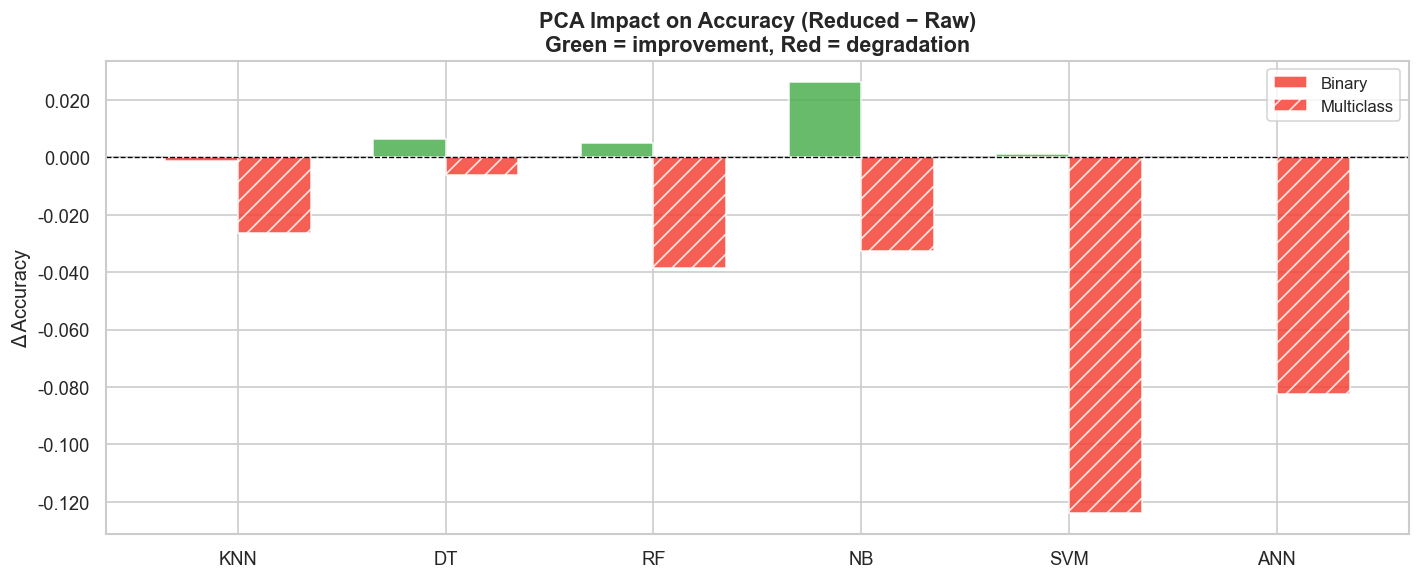

Saved: ../Results/Final_DimReduction_Impact.png


In [ ]:
raw = df[df['Features'] == 'Raw'][['Model', 'Task', 'Val_Acc', 'Val_F1', 'Train_Time']]
red = df[df['Features'] == 'Reduced'][['Model', 'Task', 'Val_Acc', 'Val_F1', 'Train_Time']]

delta = raw.merge(red, on=['Model', 'Task'], suffixes=('_raw', '_red'))
delta['Acc_Delta']  = (delta['Val_Acc_red'] - delta['Val_Acc_raw']).round(4)
delta['F1_Delta']   = (delta['Val_F1_red'] - delta['Val_F1_raw']).round(4)
delta['Time_Delta'] = (delta['Train_Time_red'] - delta['Train_Time_raw']).round(4)

print('=== PCA Impact (Reduced − Raw) ===')
display(delta[['Model', 'Task', 'Val_Acc_raw', 'Val_Acc_red', 'Acc_Delta',
               'Val_F1_raw', 'Val_F1_red', 'F1_Delta']]
        .sort_values(['Task', 'Acc_Delta']))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(MODEL_ORDER))
w = 0.35

bin_delta  = [delta.loc[(delta['Model'] == m) & (delta['Task'] == 'Binary'), 'Acc_Delta'].values[0]
              if len(delta.loc[(delta['Model'] == m) & (delta['Task'] == 'Binary')]) else np.nan
              for m in MODEL_ORDER]
multi_delta = [delta.loc[(delta['Model'] == m) & (delta['Task'] == 'Multiclass'), 'Acc_Delta'].values[0]
               if len(delta.loc[(delta['Model'] == m) & (delta['Task'] == 'Multiclass')]) else np.nan
               for m in MODEL_ORDER]

colors_bin   = ['#4CAF50' if v >= 0 else '#F44336' for v in bin_delta]
colors_multi = ['#4CAF50' if v >= 0 else '#F44336' for v in multi_delta]

ax.bar(x - w/2, bin_delta, w, color=colors_bin, alpha=0.85, label='Binary')
ax.bar(x + w/2, multi_delta, w, color=colors_multi, alpha=0.85, label='Multiclass', hatch='//')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('PCA Impact on Accuracy (Reduced − Raw)\nGreen = improvement, Red = degradation',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=11)
ax.set_ylabel('Δ Accuracy')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig('../Results/Final_DimReduction_Impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../Results/Final_DimReduction_Impact.png')

Radar chart: Val_Acc across models for all 4 settings

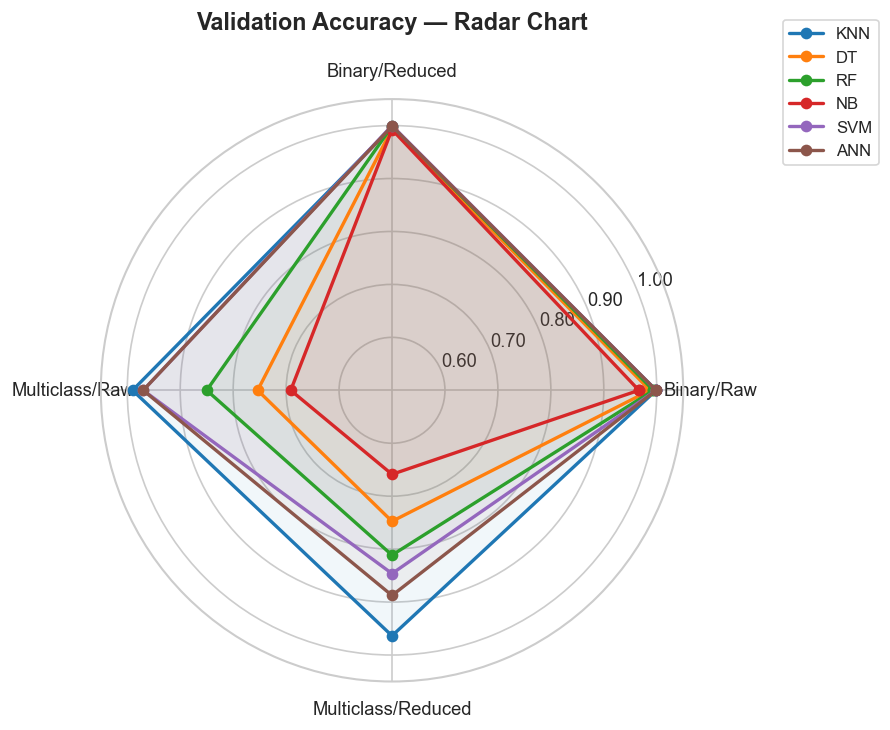

Saved: ../Results/Final_Radar_Accuracy.png


In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

settings = ['Binary/Raw', 'Binary/Reduced', 'Multiclass/Raw', 'Multiclass/Reduced']
N = len(settings)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

palette = plt.cm.tab10.colors
for i, model in enumerate(MODEL_ORDER):
    vals = []
    for task, feat in [('Binary','Raw'), ('Binary','Reduced'), ('Multiclass','Raw'), ('Multiclass','Reduced')]:
        row = df[(df['Model'] == model) & (df['Task'] == task) & (df['Features'] == feat)]
        vals.append(row['Val_Acc'].values[0] if len(row) else 0)
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=model, color=palette[i])
    ax.fill(angles, vals, alpha=0.06, color=palette[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(settings, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_title('Validation Accuracy — Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig('../Results/Final_Radar_Accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../Results/Final_Radar_Accuracy.png')

Summary

In [ ]:
best_params = df[['Model', 'Task', 'Features', 'Best_Param', 'CV_Score', 'Val_Acc', 'Val_F1']].copy()
best_params = best_params.sort_values(['Model', 'Task', 'Features']).reset_index(drop=True)
display(best_params)

,Model,Task,Features,Best_Param,CV_Score,Val_Acc,Val_F1
0,KNN,Binary,Raw,"{'metric': 'euclidean', 'n_neighbors': 1, 'wei...",0.9949,0.9988,0.9987
1,KNN,Binary,Reduced,"{'metric': 'euclidean', 'n_neighbors': 1, 'wei...",0.9944,0.9975,0.9975
2,KNN,Multiclass,Raw,"{'metric': 'euclidean', 'n_neighbors': 1, 'wei...",0.9892,0.9900,0.9900
3,KNN,Multiclass,Reduced,"{'metric': 'euclidean', 'n_neighbors': 1, 'wei...",0.9444,0.9637,0.9638
4,DT,Binary,Raw,"{'class_weight': None, 'criterion': 'entropy',...",0.9871,0.9875,0.9874
5,DT,Binary,Reduced,"{'class_weight': None, 'criterion': 'gini', 'm...",0.9942,0.9938,0.9938
6,DT,Multiclass,Raw,"{'class_weight': None, 'criterion': 'entropy',...",0.7617,0.7538,0.7402
7,DT,Multiclass,Reduced,"{'class_weight': None, 'criterion': 'gini', 'm...",0.7433,0.7475,0.7452
8,RF,Binary,Raw,"{'max_depth': 12, 'max_features': 'sqrt', 'min...",0.9928,0.9938,0.9937
9,RF,Binary,Reduced,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.9984,0.9988,0.9987


In [10]:
import sklearn, platform
print(f'Python  : {platform.python_version()}')
print(f'sklearn : {sklearn.__version__}')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')

Python  : 3.10.19
sklearn : 1.7.2
pandas  : 2.3.3
numpy   : 2.0.1
